# Support Vector Machine with a Radial Basis Function kernel

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    run_stratified_cv,
    run_seed_sweep, SweepResult,
    print_sweep_classification_report,
    print_sweep_performance_summary,
    print_sweep_error_patterns,
    plot_sweep_f1_bar, plot_sweep_confusion_matrix,
    plot_sweep_decision_scores,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=RobustScaler(),
    smote_variant="borderline",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    299
1.0    200
2.0    198
Name: count, dtype: int64
Balanced train shape: (697, 17)
Class weights: {np.int64(0): np.float64(0.7770345596432553), np.int64(1): np.float64(1.1616666666666666), np.int64(2): np.float64(1.1734006734006734)}

Outputs ready for modeling:
  X_train_bal       → (697, 17) (balanced, scaled)
  y_train_bal       → 697 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, 10],
}

grid_rbf = run_grid_search(
    SVC(kernel="rbf", class_weight=class_weight_dict, probability=True, random_state=42),
    param_grid,
    X_train_bal,
    y_train_bal,
)
svm_rbf = grid_rbf.best_estimator_

y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_prob_rbf = svm_rbf.predict_proba(X_test_scaled)
y_dec_rbf  = svm_rbf.decision_function(X_test_scaled)

print("RBF SVM training complete.")
print(f"Best C:     {grid_rbf.best_params_['C']}")
print(f"Best gamma: {grid_rbf.best_params_['gamma']}")
print(f"Best CV F1 Macro: {grid_rbf.best_score_:.4f}")
print(f"Support vectors per class: {svm_rbf.n_support_}")
print(f"Total support vectors: {svm_rbf.n_support_.sum()}/{X_train_bal.shape[0]} training samples")

RBF SVM training complete.
Best C:     10
Best gamma: 0.1
Best CV F1 Macro: 0.9761
Support vectors per class: [118  41  41]
Total support vectors: 200/697 training samples


### Seed-Sweep Evaluation

Grid search above tuned `C` and `gamma` on `random_state=42` only. The single test F1 macro from one split is a noisy estimate when minority test classes have only 6 mesoplanet and 8 psychroplanet samples. Re-evaluate with the tuned `(C, gamma)` across 50 random splits, capturing per-seed confusion matrices, decision function scores, and predicted probabilities for downstream aggregated diagnostics.

Unlike Linear SVM, RBF has no `coef_` — the decision is a non-linear function of the original features in the kernel-induced space — so there's no OvR feature-weight view here. The sweep-aware decision score plot below replaces the original single-seed version; the C × gamma heatmap stays at seed=42 because making it sweep-aware would require nested CV (50 grid searches), and the support-vector PCA scatter stays at seed=42 because PCA bases and SV identities are intrinsically per-fit.

`n_seeds=50` for fast iteration; bump to `n_seeds=500` for the final paper-grade run.

In [4]:
sweep_rbf = run_seed_sweep(
    lambda cw: SVC(
        **grid_rbf.best_params_,
        kernel="rbf",
        class_weight=cw,
        probability=True,
        random_state=42,
    ),
    df,
    n_seeds=50,
    scaler_cls=RobustScaler,
    smote_variant="borderline",
    model_name="RBF SVM",
    save_csv="sweep_rbfsvm.csv",
    save_pickle="sweep_rbfsvm.pkl",
)

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/si

RBF SVM — 50-seed sweep
  F1 macro:    0.5822 ± 0.0496  (SEM 0.0070, min 0.4545, max 0.6990)
  F1 weighted: 0.9744 ± 0.0038
  Captured per-seed: predict_proba, decision_function
  F1 DataFrame saved to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/advanced_models/../data/output/seed_sweep_results/sweep_rbfsvm.csv
  Full SweepResult pickled to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/advanced_models/../data/output/seed_sweep_results/sweep_rbfsvm.pkl


## Modeling
### DIAGNOSTIC PLOT 1: C × gamma Grid Search Heatmap

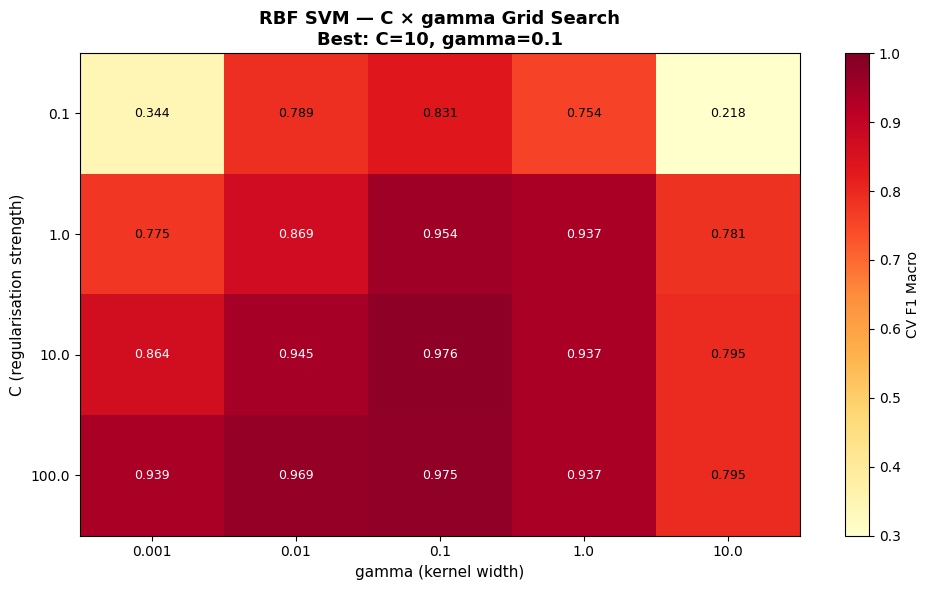

↑ gamma = kernel width: low → smooth, wide-influence boundaries; high → tight, local clusters.
  C = margin softness: low → wider margin tolerates misclassifications; high → harder margin.
  High gamma + high C is the classic overfitting corner — watch for inflated CV scores there.


In [5]:
results_df = pd.DataFrame(grid_rbf.cv_results_)
pivot = results_df.pivot_table(
    index="param_C", columns="param_gamma", values="mean_test_score",
).sort_index(axis=0).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=0.3, vmax=1.0)
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels([str(g) for g in pivot.columns], fontsize=10)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels([str(c) for c in pivot.index], fontsize=10)
ax.set_xlabel("gamma (kernel width)", fontsize=11)
ax.set_ylabel("C (regularisation strength)", fontsize=11)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=9, color="black" if val < 0.85 else "white")

plt.colorbar(im, ax=ax, label="CV F1 Macro")
ax.set_title(
    f"RBF SVM — C × gamma Grid Search\n"
    f"Best: C={grid_rbf.best_params_['C']}, gamma={grid_rbf.best_params_['gamma']}",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
save_plot("rbf_grid_heatmap")
plt.show()

print("↑ gamma = kernel width: low → smooth, wide-influence boundaries; high → tight, local clusters.")
print("  C = margin softness: low → wider margin tolerates misclassifications; high → harder margin.")
print("  High gamma + high C is the classic overfitting corner — watch for inflated CV scores there.")

### DIAGNOSTIC PLOT 2: Decision Function Score Distributions by True Class

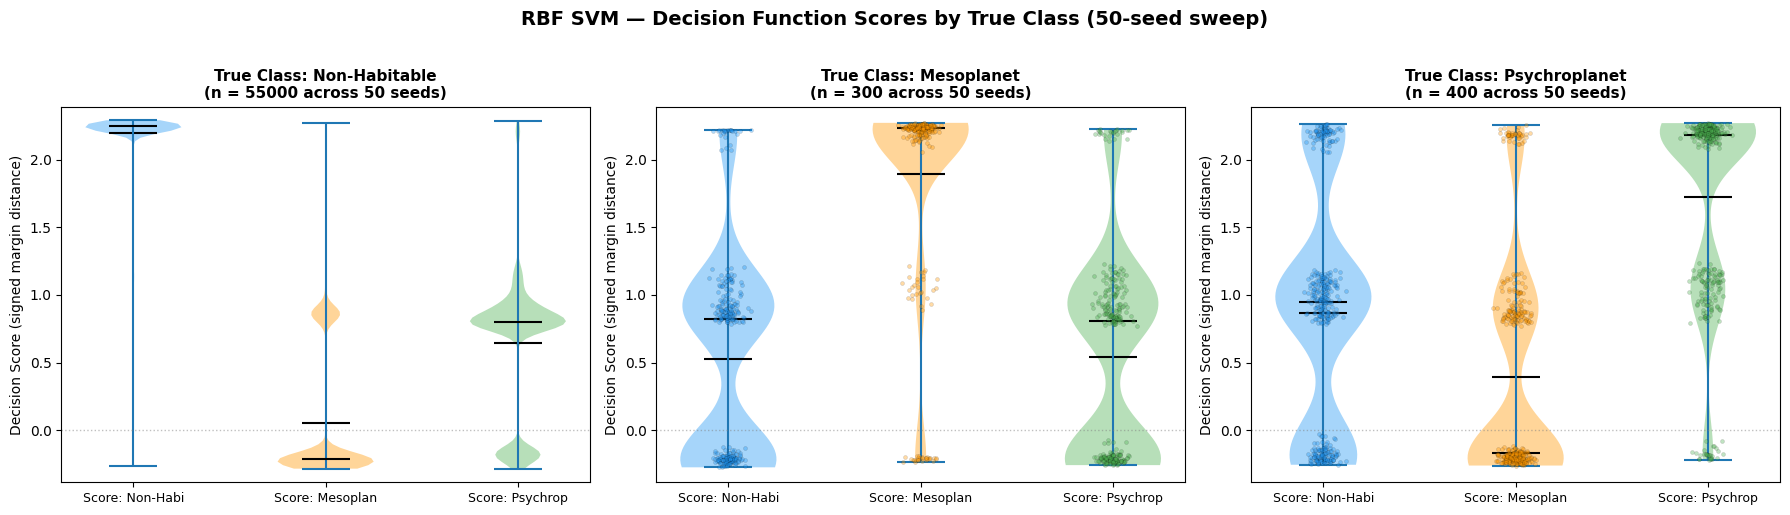

↑ Each panel = decision scores for samples whose TRUE class is labelled above,
  aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet = 300 score
  points per minority panel, the violins now carry real statistical mass.
  Scores reflect distance in RBF's kernel-induced space — expect more compressed
  margins than linear SVM, since RBF carves tighter regions around minority clusters.
  Positive score = model pushes sample TOWARD that class; 0 = decision boundary.


In [6]:
plot_sweep_decision_scores(sweep_rbf)

print("↑ Each panel = decision scores for samples whose TRUE class is labelled above,")
print("  aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet = 300 score")
print("  points per minority panel, the violins now carry real statistical mass.")
print("  Scores reflect distance in RBF's kernel-induced space — expect more compressed")
print("  margins than linear SVM, since RBF carves tighter regions around minority clusters.")
print("  Positive score = model pushes sample TOWARD that class; 0 = decision boundary.")

### DIAGNOSTIC PLOT 3: Support Vectors in PCA Space

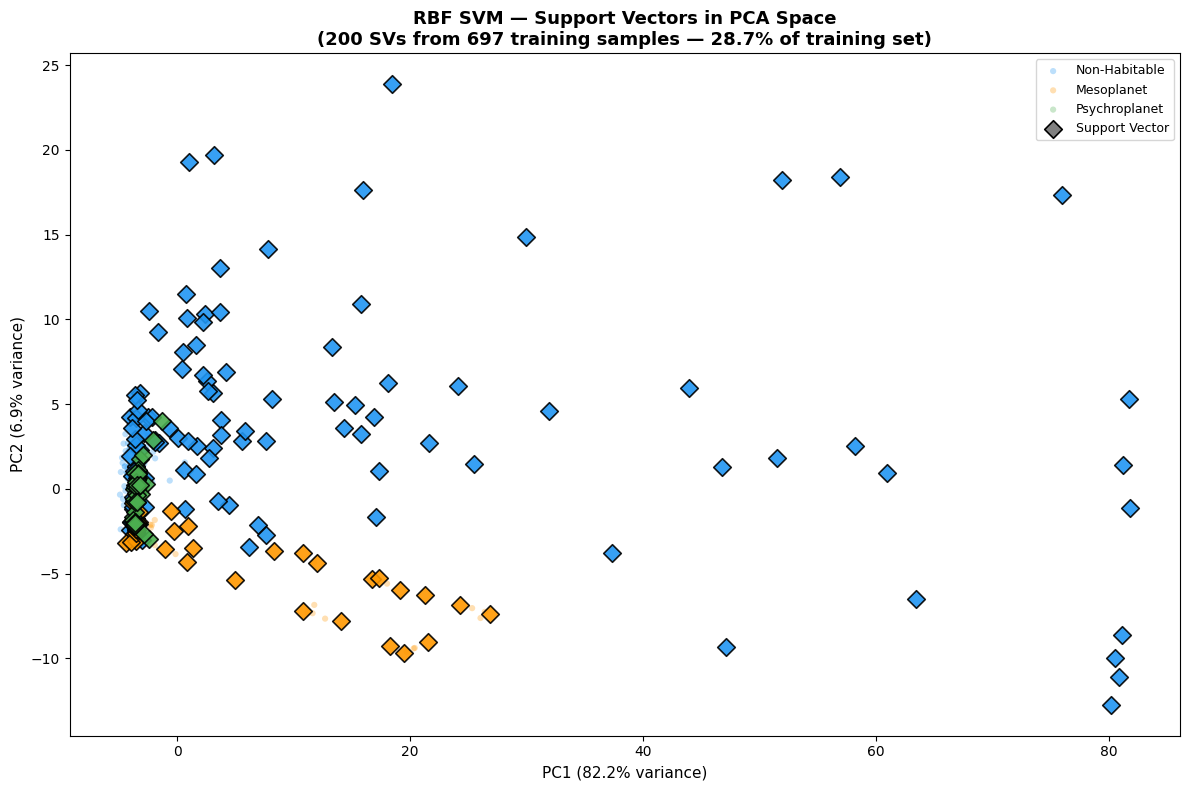

Support vectors per class: {'Non-Habitable': np.int32(118), 'Mesoplanet': np.int32(41), 'Psychroplanet': np.int32(41)}
↑ RBF typically uses a much higher fraction of training samples as SVs than linear SVM.
  Many minority-class points becoming SVs is expected — the kernel needs them to carve local regions.


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_bal)

sv_mask = np.zeros(X_train_bal.shape[0], dtype=bool)
sv_mask[svm_rbf.support_] = True

y_train_arr = y_train_bal.values if hasattr(y_train_bal, "values") else np.asarray(y_train_bal)

fig, ax = plt.subplots(figsize=(12, 8))

for i, (cls, label, color) in enumerate(zip(classes, class_names, colors)):
    mask = y_train_arr == cls
    ax.scatter(X_train_pca[mask & ~sv_mask, 0], X_train_pca[mask & ~sv_mask, 1],
               c=color, label=label, alpha=0.3, s=20, edgecolors="none")
    ax.scatter(X_train_pca[mask & sv_mask, 0], X_train_pca[mask & sv_mask, 1],
               c=color, s=80, alpha=0.9, edgecolors="black", linewidth=1.2,
               marker="D", zorder=5)

ax.scatter([], [], c="gray", s=80, marker="D", edgecolors="black",
           linewidth=1.2, label="Support Vector")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=11)
ax.set_title(
    f"RBF SVM — Support Vectors in PCA Space\n"
    f"({svm_rbf.n_support_.sum()} SVs from {X_train_bal.shape[0]} training samples — "
    f"{svm_rbf.n_support_.sum() / X_train_bal.shape[0]:.1%} of training set)",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=9)
plt.tight_layout()
save_plot("rbf_support_vectors_pca")
plt.show()

print(f"Support vectors per class: {dict(zip(class_names, svm_rbf.n_support_))}")
print("↑ RBF typically uses a much higher fraction of training samples as SVs than linear SVM.")
print("  Many minority-class points becoming SVs is expected — the kernel needs them to carve local regions.")

## Metrics
### Classification Report + F1 Scores

RBF SVM — Classification Report (50-seed sweep)
Class               F1 mean     F1 std     F1 min     F1 max
----------------------------------------------------------------
Non-Habitable        0.9822     0.0032     0.9754     0.9876
Mesoplanet           0.5121     0.1180     0.1667     0.7692
Psychroplanet        0.2522     0.0613     0.0714     0.3784
----------------------------------------------------------------
Macro avg            0.5822     0.0496     0.4545     0.6990
Weighted avg         0.9744     0.0038     0.9670     0.9804

5-Fold CV F1 Macro: 0.9789 ± 0.0098

RBF SVM — Performance Summary (50-seed sweep)

Per-class Precision and Recall (mean ± std)
                 Precision            Recall              
Non-Habitable    0.9977 ± 0.0012    0.9672 ± 0.0064
Mesoplanet       0.3869 ± 0.1229    0.8167 ± 0.1790
Psychroplanet    0.1572 ± 0.0397    0.6600 ± 0.1786
----------------------------------------------------------------
Macro avg        0.5139 ± 0.0468    0.8146 ± 0.

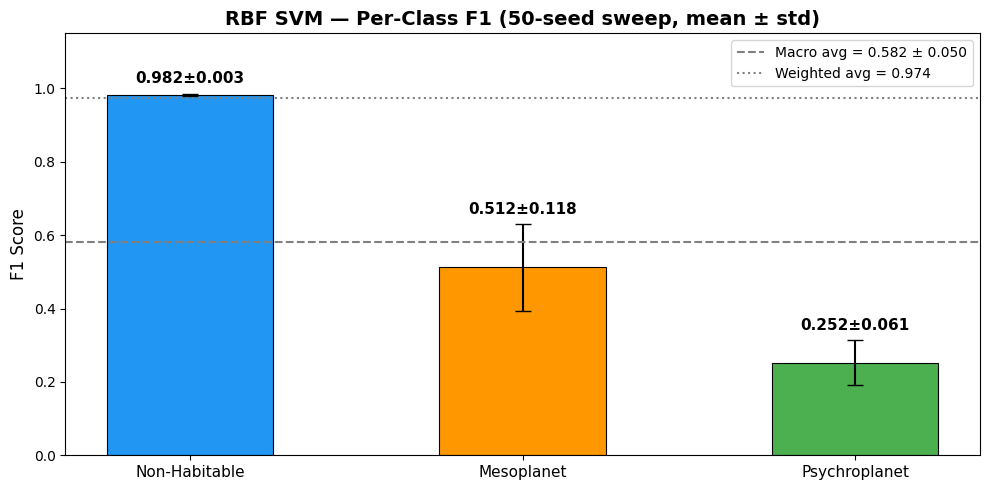

In [8]:
# Per-class F1 with mean ± std from the seed sweep
print_sweep_classification_report(sweep_rbf)

# 5-fold CV on the balanced training set — orthogonal to sweep variance,
# measures within-seed tuning stability (different question).
cv_scores_rbf = run_stratified_cv(svm_rbf, X_train_bal, y_train_bal)

# Cross-model comparison metrics: per-class P/R + aggregate robustness scores
# (MCC, balanced accuracy, minority F1 macro)
print_sweep_performance_summary(sweep_rbf)

# Per-class bar chart with error bars from the sweep distribution
plot_sweep_f1_bar(sweep_rbf)

### Confusion Matrix (Counts + Normalized)

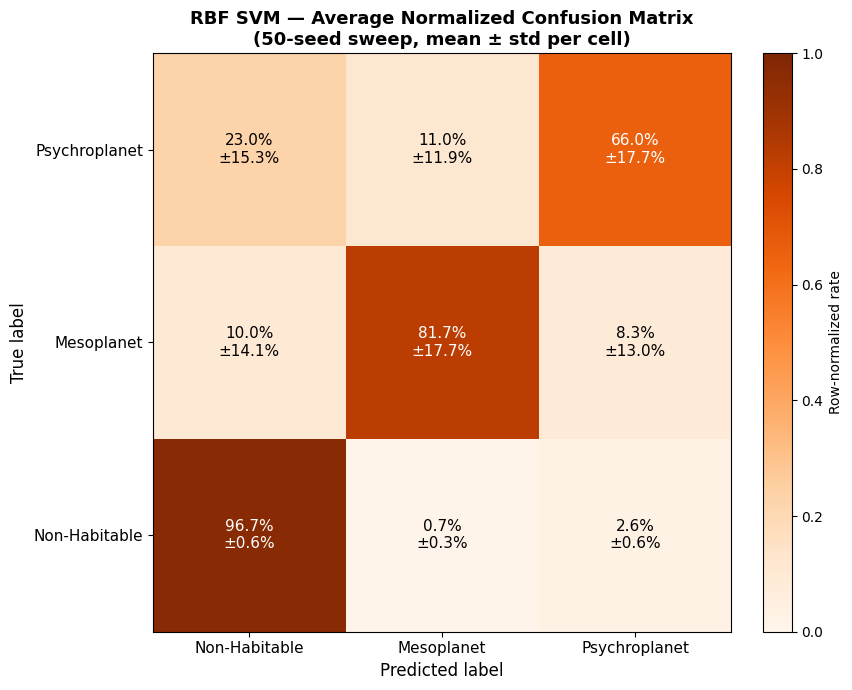

Key error patterns (50-seed sweep):
  Non-Habitable → predicted Mesoplanet: 7.90 ± 3.80 per split  (0.7% ± 0.3% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 28.18 ± 6.31 per split  (2.6% ± 0.6% of true Non-Habitable)
  Mesoplanet → predicted Non-Habitable: 0.60 ± 0.85 per split  (10.0% ± 14.1% of true Mesoplanet)
  Mesoplanet → predicted Psychroplanet: 0.50 ± 0.78 per split  (8.3% ± 13.0% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 1.84 ± 1.22 per split  (23.0% ± 15.3% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 0.88 ± 0.95 per split  (11.0% ± 11.9% of true Psychroplanet)


In [9]:
# Average row-normalized CM across all 50 seeds, annotated per-cell with std
plot_sweep_confusion_matrix(sweep_rbf)

# Off-diagonal patterns: per-split count and per-class rate, both mean ± std
print_sweep_error_patterns(sweep_rbf)

## Interpretation:
